# 01 — SMS Spam: Exploratory Data Analysis

**Dataset:** SMS Spam Collection v.1 (UCI). 5,574 English SMS messages, hand-labelled
`ham` or `spam`.

**What this notebook is for.** Before any modelling, establish three things:

1. How imbalanced the target is — this decides which metric is worth reporting later.
2. Whether the corpus has duplicate messages, and how many. Duplicates that survive
   into a train/test split put the same message on both sides of it.
3. Whether *message shape* — length, digits, capitalisation, punctuation — separates
   the two classes at all. If it does not, the feature set planned for notebook 02
   is a dead end and it is better to find that out here.

**A note on printed samples.** This corpus is real traffic and contains working
phone numbers, shortcodes and first names, and notebook outputs are saved inside the
committed `.ipynb`. Every message printed below goes through `redact()` first, which
replaces identifying spans with type placeholders and then truncates. Sample rows
exist here to show the *shape* of a message, and shape is all this project uses.

**Section order:** imports → data loading → EDA → preprocessing → modelling → evaluation.

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Make `src` importable when the notebook is run from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.loader import read_csv_safe, summarise_duplicates
from src.utils.redaction import safe_sample, redact
from src.utils.plotstyle import CLASS_COLORS, SERIES, apply_style, despine, annotate_bars
from src.features.spam_features import FEATURE_ORDER, build_feature_frame

apply_style()
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 2.2.3 | numpy 1.26.4 | seaborn 0.13.2


## 2. Data loading

The file ships as tab-separated with **no header row**, so column names are supplied
explicitly.

`quoting=3` (`csv.QUOTE_NONE`) is not optional here. Message bodies contain bare
double-quote characters, and with default quoting pandas treats one as the start of a
quoted field and swallows everything up to the next one — silently merging rows and
losing messages. Turning quote handling off entirely is correct for a file that has no
quoting convention to begin with.

`read_csv_safe` tries UTF-8 first and falls back to Latin-1, then reports which one it
actually used rather than guessing quietly.

In [2]:
raw = read_csv_safe(
    ROOT / "data" / "SMSSpamCollection.tsv",
    sep="\t",
    header=None,
    names=["label", "message"],
    quoting=3,
)
sms = raw.frame
print()
print(f"encoding reported : {raw.encoding}")
print(f"used a fallback   : {raw.used_fallback}")
print(f"shape             : {sms.shape}")

Loaded SMSSpamCollection.tsv: 5,574 rows x 2 cols using encoding 'utf-8'

encoding reported : utf-8
used a fallback   : False
shape             : (5574, 2)


### On the encoding

The brief describes this file as Latin-1. **The UCI zip distribution is in fact valid
UTF-8** — the loader decodes it as UTF-8 and the non-ASCII characters come through
correctly (`£`, `é` and so on appear intact in the samples below, with no `�`
replacement characters).

That is not a contradiction so much as a version difference. The widely-circulated
Kaggle mirror of this dataset (`spam.csv`) *is* Latin-1/CP-1252 encoded and does fail a
strict UTF-8 read — which is why almost every tutorial using it passes
`encoding='latin-1'` explicitly.

This is exactly the situation the loader was built for: hard-coding either encoding
would be wrong for one of the two distributions, and hard-coding Latin-1 would
silently mojibake this file (Latin-1 never raises — it maps all 256 byte values —
so `£` would have become `Â£` with no error at all). Detecting and reporting is the
only approach that is right for both. The Latin-1 path is exercised in
`tests/test_loader.py` against a fixture built for it.

In [3]:
non_ascii = sms["message"].str.contains(r"[^\x00-\x7F]", regex=True)
print(f"messages with non-ASCII characters: {non_ascii.sum()}")
print(f"replacement chars (mojibake tell) : {sms['message'].str.contains(chr(0xFFFD)).sum()}")
print()
for text in sms.loc[non_ascii, "message"].head(3):
    print("  •", redact(text, max_chars=88))

messages with non-ASCII characters: 483
replacement chars (mojibake tell) : 0

  • FreeMsg Hey there darling it's been <NUM> week's now and no word back! I'd like some fu…
  • WINNER!! As a valued network customer you have been selected to receivea <MONEY> prize…
  • URGENT! You have won a <NUM> week FREE membership in our <MONEY> Prize <NAME>! Txt the…


### Duplicates

Counted here, **dropped in notebook 02 before the split** — the count is an EDA finding,
and the drop belongs next to the split it protects.

In [4]:
print(summarise_duplicates(sms))
print(summarise_duplicates(sms, subset="message"))

dupes = sms[sms.duplicated(subset="message", keep=False)].sort_values("message")
print(f"\nrows involved in a duplicate group: {len(dupes):,}")
print(f"distinct messages among them      : {dupes['message'].nunique():,}")

top = dupes["message"].value_counts().head(5)
print("\nmost-repeated messages:")
for text, n in top.items():
    print(f"  {n:>3}x  {redact(text, max_chars=70)}")

403 duplicate rows (7.2% of 5,574)
403 duplicate values of message (7.2% of 5,574)

rows involved in a duplicate group: 684
distinct messages among them      : 281

most-repeated messages:
   30x  Sorry, I'll call later
   12x  I cant pick the phone right now. <NAME> send a message
   10x  Ok...
    4x  <NAME> this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART W…
    4x  <NAME> ur lovable bcums angry wid u, dnt take it seriously.. <NAME> b…


Note what the repeats are: short, generic ham (`"Ok"`, `"Sorry, I'll call later"`).
These are real, independently-sent messages that happen to share a body — but a model
cannot tell them apart, so if one copy trains and another tests, that test row is
scored on memorised text. 403 of 5,574 rows is 7.2%, enough to move a reported score.

## 3. Exploratory data analysis

### 3.1 Class balance

,messages,share
label,,
ham,4827,86.6%
spam,747,13.4%


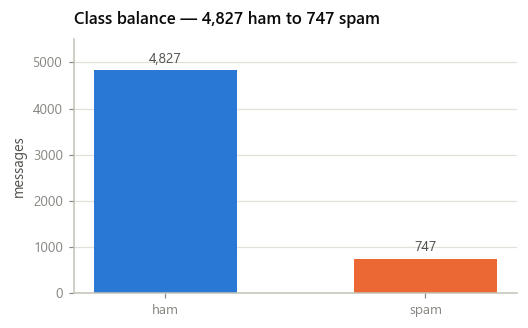


majority class share: 86.6%
a model that predicts 'ham' for every row scores 86.6% accuracy while catching zero spam.


In [5]:
counts = sms["label"].value_counts()
shares = sms["label"].value_counts(normalize=True)

summary = pd.DataFrame({"messages": counts, "share": shares})
summary["share"] = summary["share"].map("{:.1%}".format)
display(summary)

fig, ax = plt.subplots(figsize=(5.2, 3.0))
order = ["ham", "spam"]
bars = ax.bar(order, [counts[k] for k in order],
              color=[CLASS_COLORS[k] for k in order], width=0.55)
annotate_bars(ax, fmt="{:,.0f}")
ax.set_title("Class balance — 4,827 ham to 747 spam")
ax.set_ylabel("messages")
ax.grid(axis="x", visible=False)
despine(ax)
plt.show()

print(f"\nmajority class share: {shares.max():.1%}")
print(f"a model that predicts '{shares.idxmax()}' for every row scores "
      f"{shares.max():.1%} accuracy while catching zero spam.")

**This is the single most consequential fact in the dataset.** 86.6% of rows are `ham`.
Accuracy is therefore near-useless as a headline number: the do-nothing classifier that
labels everything `ham` scores 86.6% and never catches a single spam message. Notebook
02 reports precision, recall and F1 **for the spam class** instead, and says so
explicitly at the point it prints accuracy.

### 3.2 Message length by class

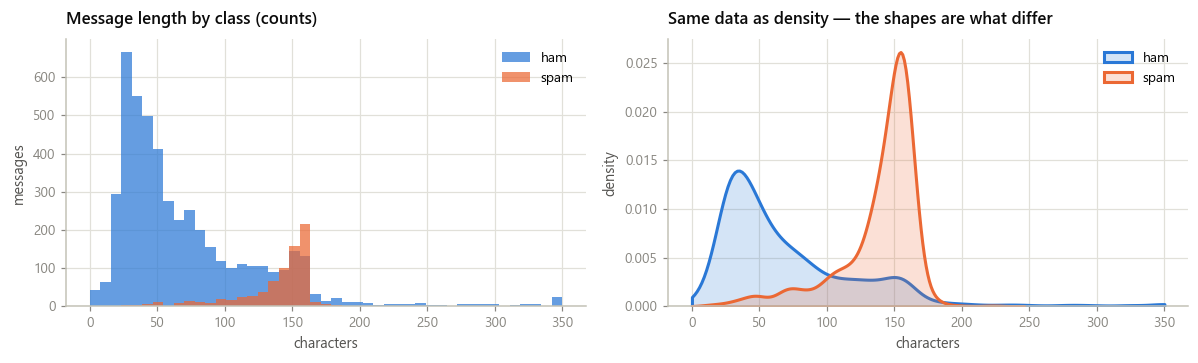

,count,mean,median,std,min,max
label,,,,,,
ham,4827,71.5,52.0,58.3,2,910
spam,747,138.7,149.0,28.9,13,223


In [6]:
lengths = sms.assign(char_length=sms["message"].str.len())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

# Shared bins so the two histograms are directly comparable. Clipped at 350
# because a handful of very long ham messages would otherwise flatten everything.
bins = np.linspace(0, 350, 46)
for label in ["ham", "spam"]:
    axes[0].hist(lengths.loc[lengths.label == label, "char_length"].clip(upper=350),
                 bins=bins, alpha=0.72, label=label, color=CLASS_COLORS[label])
axes[0].set_title("Message length by class (counts)")
axes[0].set_xlabel("characters")
axes[0].set_ylabel("messages")
axes[0].legend(title=None)
despine(axes[0])

# Density, because the raw counts are dominated by ham being 6.5x more common.
for label in ["ham", "spam"]:
    sns.kdeplot(lengths.loc[lengths.label == label, "char_length"].clip(upper=350),
                ax=axes[1], label=label, color=CLASS_COLORS[label], fill=True,
                alpha=0.20, linewidth=2, clip=(0, 350))
axes[1].set_title("Same data as density — the shapes are what differ")
axes[1].set_xlabel("characters")
axes[1].set_ylabel("density")
axes[1].legend(title=None)
despine(axes[1])

plt.tight_layout()
plt.show()

display(lengths.groupby("label")["char_length"]
        .agg(["count", "mean", "median", "std", "min", "max"]).round(1))

Both panels show the same column. The left one answers "how many messages", the right
one "what does each class look like" — and because ham outnumbers spam 6.5:1, the
count plot alone would hide the spam distribution entirely.

The separation is real and strong: ham has a median of 52 characters and a long thin
tail, spam clusters tightly around 150. Spam is written to fill the 160-character SMS
limit; ordinary texting is much shorter.

### 3.3 Digit ratio and uppercase ratio

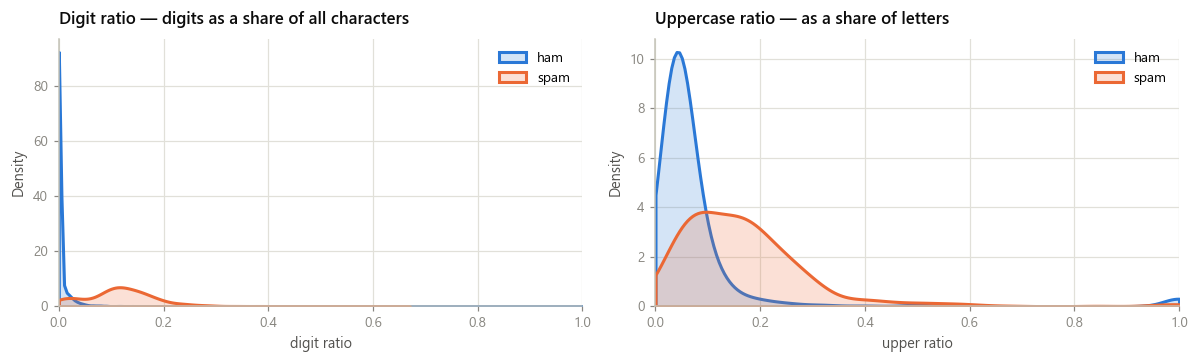

digit_ratio        upper_ratio       
             mean median        mean median
label                                      
ham         0.004  0.000       0.079  0.045
spam        0.117  0.117       0.167  0.148

In [7]:
ratios = sms.assign(
    digit_ratio=sms["message"].map(
        lambda t: sum(c.isdigit() for c in t) / len(t) if len(t) else 0.0),
    upper_ratio=sms["message"].map(
        lambda t: (sum(c.isupper() for c in t if c.isalpha())
                   / max(1, sum(c.isalpha() for c in t)))),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, column, title in [
    (axes[0], "digit_ratio", "Digit ratio — digits as a share of all characters"),
    (axes[1], "upper_ratio", "Uppercase ratio — as a share of letters"),
]:
    for label in ["ham", "spam"]:
        sns.kdeplot(ratios.loc[ratios.label == label, column], ax=ax, label=label,
                    color=CLASS_COLORS[label], fill=True, alpha=0.20,
                    linewidth=2, clip=(0, 1))
    ax.set_title(title)
    ax.set_xlabel(column.replace("_", " "))
    ax.set_xlim(0, 1)
    ax.legend(title=None)
    despine(ax)
plt.tight_layout()
plt.show()

display(ratios.groupby("label")[["digit_ratio", "upper_ratio"]]
        .agg(["mean", "median"]).round(3))

**Digit ratio separates the classes sharply.** 88% of ham messages are under 1% digits,
against 6% of spam; 28% of spam is over 15% digits, against 0.1% of ham. Spam carries
shortcodes, premium numbers and prize amounts, and ordinary texting does not.

**Uppercase ratio is weaker, and not in the way one might guess.** The intuition is
that spam SHOUTS — but the fully-capitalised tail is not where the signal is: only
0.9% of spam is more than 80% uppercase, and ham actually beats it there (2.2%,
mostly very short messages like `"OK"` where one word sets the ratio). The real
difference is at the quiet end: **86.7% of ham sits below 10% uppercase, against
33.2% of spam.** Spam is *consistently, moderately* capitalised — `Free`, `Claim`,
`WINNER` scattered through a normal sentence — rather than uniformly shouted. That
shifts the whole distribution rather than adding a second peak, which is why the
effect size is modest (*d* = 0.61) despite the class means differing two-fold.

Using a ratio rather than a raw count is what makes this comparable across messages
of different lengths at all.

Both are computed here inline over the raw column purely for the plot. The versions
used for modelling live in `src/features/spam_features.py` as standalone functions, so
notebook 02 and the tests share exactly one definition of each.

### 3.4 Sample rows (redacted)

In [8]:
sample = safe_sample(sms, n=6, group_by="label", random_state=7, max_chars=76)
display(sample.reset_index(drop=True))

,label,message
0,ham,Oh dang! I didn't mean o send that to you! <NA...
1,ham,Yes. that will be fine. Love you. Be safe.
2,ham,"swhrt how u dey,hope ur ok, tot about u 2day.l..."
3,ham,Am I the only one who doesn't stalk profiles?
4,ham,Oh did you charge camera
5,ham,You flippin your shit yet?
6,spam,"Free msg. Sorry, a service you ordered from <N..."
7,spam,<NUM> FREE for 1st week! No1 <NAME> tone <NUM>...
8,spam,You have won a <NAME> 7250i. This is what you ...
9,spam,<NAME> you know is trying to contact you via o...


`<PHONE>`, `<NAME>`, `<MONEY>`, `<URL>` and `<NUM>` are placeholders substituted by
`redact()`. The underlying frame is untouched — this is a display filter, applied only
where rows are printed.

Even redacted, the difference in register is obvious: ham is conversational and
lower-case, spam is imperative, capitalised, and full of numbers and money.

## 4. Preprocessing

Preprocessing in *this* notebook is limited to deriving the 12 features so their
distributions can be inspected. **No split, no scaling, no imputation happens here** —
those belong in notebook 02, where they sit next to the model that consumes them.

The 12 features are the ones defined in `src/features/spam_features.py`.

In [9]:
features = build_feature_frame(sms["message"])
frame = pd.concat([sms[["label"]], features], axis=1)

print(f"{features.shape[1]} features engineered for {features.shape[0]:,} messages")
print("no missing values:", not features.isna().any().any())
display(features.describe().T.round(3))

12 features engineered for 5,574 messages
no missing values: True


,count,mean,std,min,25%,50%,75%,max
char_length,5574.0,80.478,59.848,2.0,36.000,62.000,122.000,910.0
word_count,5574.0,15.592,11.390,1.0,7.000,12.000,23.000,171.0
mean_word_length,5574.0,4.277,1.146,1.5,3.667,4.111,4.679,49.0
digit_count,5574.0,2.383,6.252,0.0,0.000,0.000,1.000,47.0
digit_ratio,5574.0,0.019,0.049,0.0,0.000,0.000,0.007,1.0
uppercase_ratio,5574.0,0.091,0.149,0.0,0.033,0.050,0.083,1.0
all_caps_word_count,5574.0,0.639,2.468,0.0,0.000,0.000,0.000,32.0
exclamation_count,5574.0,0.251,0.687,0.0,0.000,0.000,0.000,11.0
currency_symbol_count,5574.0,0.063,0.296,0.0,0.000,0.000,0.000,3.0
non_alnum_count,5574.0,4.276,4.657,0.0,2.000,3.000,6.000,133.0


## 5. Modelling

The model in an EDA notebook is a **baseline, not a result** — it exists to answer one
question before notebook 02 commits to this feature set: *does message shape separate
the classes at all?*

Two cheap checks, no train/test split (nothing here is being reported as a score):

1. **Standardised mean difference (Cohen's _d_)** per feature — how far apart the two
   class means are, in pooled standard deviations. This is a univariate ranking, so it
   is blind to interactions, but it is enough to tell a dead feature from a live one.
2. **A single-feature decision stump** per feature, scored on the training data by
   spam-class F1 — the best a one-threshold rule can do.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

y = (sms["label"] == "spam").astype(int)


def cohens_d(values: pd.Series, target: pd.Series) -> float:
    a, b = values[target == 1], values[target == 0]
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                     / (len(a) + len(b) - 2))
    return 0.0 if pooled == 0 else (a.mean() - b.mean()) / pooled


rows = []
for name in FEATURE_ORDER:
    column = features[[name]]
    stump = DecisionTreeClassifier(max_depth=1, random_state=42).fit(column, y)
    rows.append({
        "feature": name,
        "cohens_d": cohens_d(features[name], y),
        "stump_f1_spam": f1_score(y, stump.predict(column), pos_label=1),
        "ham_mean": features.loc[y == 0, name].mean(),
        "spam_mean": features.loc[y == 1, name].mean(),
    })

separation = (pd.DataFrame(rows)
              .sort_values("cohens_d", key=abs, ascending=False, ignore_index=True))
display(separation.round(3))

,feature,cohens_d,stump_f1_spam,ham_mean,spam_mean
0,digit_count,4.638,0.897,0.305,15.813
1,digit_ratio,3.584,0.855,0.004,0.117
2,has_long_digit_run,2.969,0.705,0.001,0.546
3,currency_symbol_count,1.690,0.502,0.005,0.439
4,char_length,1.215,0.000,71.472,138.676
5,has_url_like,1.213,0.309,0.003,0.186
6,word_count,0.881,0.000,14.304,23.912
7,exclamation_count,0.837,0.000,0.177,0.730
8,all_caps_word_count,0.767,0.682,0.394,2.225
9,mean_word_length,0.718,0.000,4.170,4.969


## 6. Evaluation

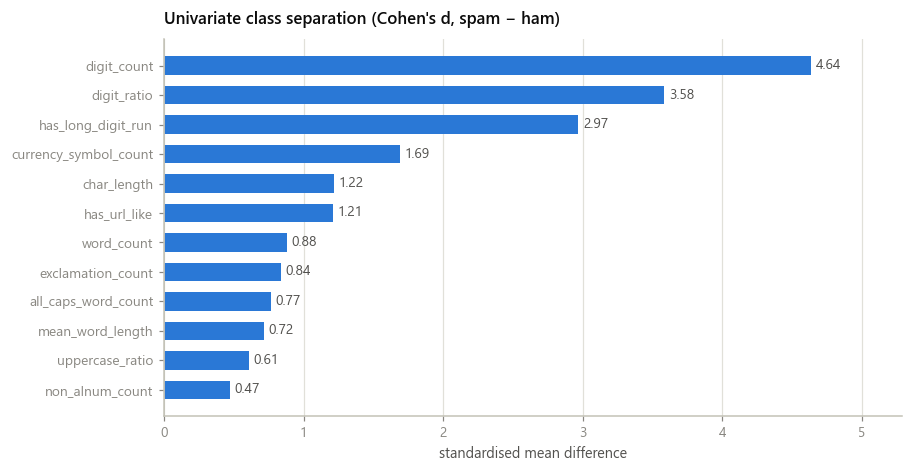

In [11]:
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ordered = separation.sort_values("cohens_d", key=abs)
ax.barh(ordered["feature"], ordered["cohens_d"], color=SERIES[0], height=0.62)
annotate_bars(ax, fmt="{:.2f}", horizontal=True)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title("Univariate class separation (Cohen's d, spam − ham)")
ax.set_xlabel("standardised mean difference")
ax.grid(axis="y", visible=False)
despine(ax)
plt.tight_layout()
plt.show()

In [12]:
strongest = separation.head(3)
weakest = separation.tail(3)
best_stump = separation.sort_values("stump_f1_spam", ascending=False).iloc[0]

print("strongest separators:")
for _, r in strongest.iterrows():
    print(f"  {r['feature']:<24} d = {r['cohens_d']:+.2f}   "
          f"ham {r['ham_mean']:.2f} → spam {r['spam_mean']:.2f}")
print("\nweakest separators:")
for _, r in weakest.iterrows():
    print(f"  {r['feature']:<24} d = {r['cohens_d']:+.2f}")
print(f"\nbest single-feature stump: {best_stump['feature']} "
      f"→ spam F1 {best_stump['stump_f1_spam']:.3f}")

strongest separators:
  digit_count              d = +4.64   ham 0.31 → spam 15.81
  digit_ratio              d = +3.58   ham 0.00 → spam 0.12
  has_long_digit_run       d = +2.97   ham 0.00 → spam 0.55

weakest separators:
  mean_word_length         d = +0.72
  uppercase_ratio          d = +0.61
  non_alnum_count          d = +0.47

best single-feature stump: digit_count → spam F1 0.897


### Findings

1. **Message shape does separate the classes, and the numbers carry it.** Six of the
   twelve features clear |*d*| > 1, which is a large effect. The top three are all
   digit-related — `digit_count` (*d* = 4.64), `digit_ratio` (3.58) and
   `has_long_digit_run` (2.97) — which fits the domain: spam has to include a number
   to call, text or pay. The feature set planned for notebook 02 is worth building.

2. **One feature already gets most of the way, which sets the bar for notebook 02.**
   A single-threshold stump on `digit_count` reaches spam F1 **0.897**. That is a
   genuinely high bar, not a strawman, and it means the multivariate model has to be
   judged against ~0.90 rather than against the majority-class baseline of 0.0.
   Reporting "F1 0.9" in notebook 02 without this number for comparison would make an
   ordinary result look impressive.

3. **Five features score a stump F1 of exactly 0.000** — `char_length`, `word_count`,
   `exclamation_count`, `mean_word_length`, `non_alnum_count` — despite two of them
   having *d* > 0.8. This is the class imbalance biting, not a bug: with 86.6% ham, a
   depth-1 tree minimising impurity puts *both* leaves on `ham`, so it never predicts
   the positive class and F1 is undefined-as-zero. It is a small preview of exactly
   why accuracy is the wrong headline metric here.

4. **No feature is dead.** The weakest, `non_alnum_count`, still separates at
   *d* = 0.47. All twelve are kept: they are cheap, tree ensembles tolerate
   uninformative inputs, and the brief specifies these twelve. The forest's importance
   ranking in notebook 02 will show whether this ordering survives contact with
   interactions — Cohen's *d* is univariate and cannot see them.

5. **Accuracy must not be the headline metric.** At 86.6% majority class, the
   do-nothing model already scores 86.6%.

6. **403 duplicate messages must be dropped before splitting**, not after.

### What notebook 02 does with this

Drops the duplicates, engineers the same 12 features, splits 80/20 stratified with
`random_state=42`, scales **after** splitting with statistics fitted on the training
partition only, and fits a decision tree and a 200-tree random forest — reporting
precision, recall and F1 for the spam class.